# Survey plotting

Notebook version of `plot_survey.py` with the same plotting logic.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Survey - Model Sharing (Responses) - Form Responses.csv")

cases = {
    "safe_mode=False": 4,
    "safe_mode=True": 6,
    "weights_only=False": 8,
    "weights_only=True": 10,
}

comf_df = pd.DataFrame({
    label: pd.to_numeric(df.iloc[:, comf_idx], errors="coerce")
            .dropna()
            .astype(int)
    for label, comf_idx in cases.items()
})

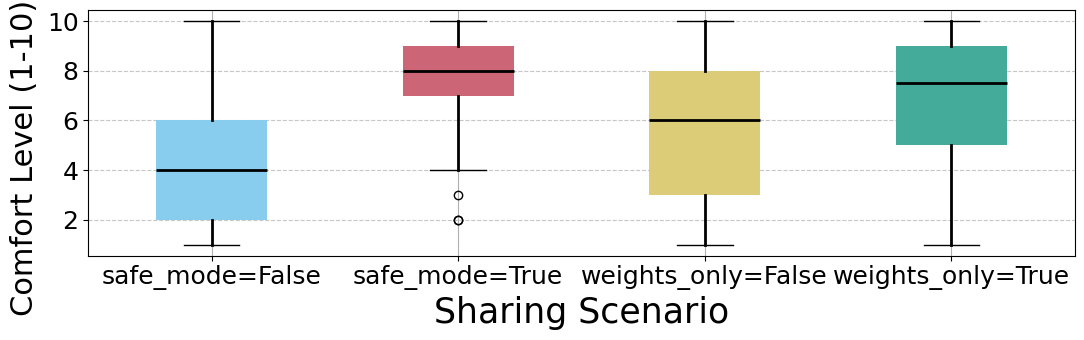

In [3]:
plt.figure(figsize=(11, 3.5))

box_plot_dict = comf_df.boxplot(patch_artist=True,
                                return_type='dict',
                                medianprops=dict(color="black", linewidth=2),
                                whiskerprops=dict(linewidth=2))

colors = ['#88CCEE', '#CC6677', '#DDCC77', '#44AA99']
for patch, color in zip(box_plot_dict['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('none')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel("Comfort Level (1-10)", fontsize=22)
plt.gca().yaxis.set_label_coords(-0.05, 0.40)
plt.xlabel("Sharing Scenario", fontsize=25)

plt.xticks(rotation=0, ha="center", fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("boxplot_updated.pdf")
plt.show()